In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import timedelta
import matplotlib.ticker as tkr
from sklearn.cluster import KMeans

def custom_grouping(index):
    return index // 1000

names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv(f'/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

In [3]:
df1 = pd.read_csv('/home/surbhi/measurements/pause-test/round1/run1/lat_log_avg_lat.1.log', sep=',', names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df1['duration'] = df1['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
df1['cumulative_gb'] = np.floor(df1['write_size'].cumsum() / (1024**3))
df1['submission_time'] = df1['submission_time'] - df1.iloc[0].submission_time
df1['completion_time'] = np.floor(df1['submission_time'] + df1['duration'])

In [4]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df1['submission_time'].min())
end_time = int(math.ceil(df1['completion_time'].max()))


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms1 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms1['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df1.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms1.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms1.loc[end] += residue

print(index)
data_written_ms1.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms1[data_written_ms1.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms1.loc[:last_non_zero_index]

/tmp/ipykernel_14283/507860518.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128 18066.9658128 18066.9658128
 18066.9658128 18066.9658128 18066.9658128]' has dtype incompat

35839


In [5]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms1), chunk_size):
    chunk = data_written_ms1.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped1 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped1.reset_index(inplace=True)
df_grouped1['cumulative_gb'] = df_grouped1['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped1['data_written_bytes'] = df_grouped1['data_written_bytes'] / (1024 ** 2) 
df_grouped1.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped1[df_grouped1.ne(0).any(axis=1)].index[-1]
df_grouped1 = df_grouped1.loc[:last_non_zero_index]
df_grouped1['latency'] =1 / df_grouped1['data_written_bytes']
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped1.describe())
print(df_grouped1.info())

# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped1[df_grouped1['data_written_bytes'] < 10]
# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']
# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb_run1 = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45
print("cache size: ", first_cumulative_gb_run1)
cache_size_run1 = first_cumulative_gb_run1

             index  data_written_bytes  cumulative_gb      latency
count  1434.000000         1434.000000    1434.000000  1434.000000
mean    716.500000           24.993026      28.702920          inf
std     414.104455           43.248710       7.513739          NaN
min       0.000000            0.000000       0.104196     0.006482
25%     358.250000            5.804047      28.765615     0.146607
50%     716.500000            6.336537      30.899357     0.157815
75%    1074.750000            6.820956      33.036025     0.172294
max    1433.000000          154.277186      35.000000          inf
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1434 entries, 0 to 1433
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1434 non-null   int64  
 1   data_written_bytes  1434 non-null   float64
 2   cumulative_gb       1434 non-null   float64
 3   latency             1434 non-null   float

In [6]:
df2= pd.read_csv('/home/surbhi/measurements/pause-test/round1/run2/lat_log_avg_lat.1.log', sep=',' , names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df2['duration'] = df2['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
df2['cumulative_gb'] = np.floor(df2['write_size'].cumsum() / (1024**3))
df2['submission_time'] = df2['submission_time'] - df2.iloc[0].submission_time #+ df_grouped1.index.max() + 60 * 60
df2['completion_time'] = np.floor(df2['submission_time'] + df2['duration'])

In [7]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df2['submission_time'].min())
end_time = int(df2['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms2 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms2['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df2.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms2.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms2.loc[end] += residue

print(index)
data_written_ms2.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms2[data_written_ms2.ne(0).any(axis=1)].index[-1]
data_written_ms2 = data_written_ms2.loc[:last_non_zero_index]

/tmp/ipykernel_14283/840144846.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[206.23351105 206.23351105 206.23351105 ... 206.23351105 206.23351105
 206.23351105]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms2.loc[start:end-1] += write_rate_per_ms


35839


In [8]:
chunk_size = 100000
results = []

for i in range(0, len(data_written_ms2), chunk_size):
    chunk = data_written_ms2.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped2 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped2.reset_index(inplace=True)
df_grouped2['cumulative_gb'] = df_grouped2['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped2['data_written_bytes'] = df_grouped2['data_written_bytes'] / (1024 ** 2) 
df_grouped2.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped2[df_grouped2.ne(0).any(axis=1)].index[-1]
df_grouped2 = df_grouped2.loc[:last_non_zero_index]
df_grouped2['latency'] =1 / df_grouped2['data_written_bytes']
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped2.describe())
print(df_grouped2.info())

# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped2[df_grouped2['data_written_bytes'] < 10]
# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']
# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb_run2 = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45
#plt.axvline(x=first_cumulative_gb, color='black', linestyle=':', label="cache size: " + str(round(first_cumulative_gb, 10)) + "GB")
print("cache size: ", first_cumulative_gb_run2 * 1024)

             index  data_written_bytes  cumulative_gb      latency
count  5150.000000         5150.000000    5150.000000  5150.000000
mean   2574.500000            6.959223      17.307455     0.184749
std    1486.821274            1.721489      10.284348     0.706438
min       0.000000            0.031507       0.002624     0.060307
25%    1287.250000            6.028187       8.313785     0.126634
50%    2574.500000            6.852809      17.239522     0.145926
75%    3861.750000            7.896782      26.275536     0.165887
max    5149.000000           16.581933      35.000000    31.738911
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               5150 non-null   int64  
 1   data_written_bytes  5150 non-null   float64
 2   cumulative_gb       5150 non-null   float64
 3   latency             5150 non-null   float

In [9]:
df3 = pd.read_csv('/home/surbhi/measurements/pause-test/round1/run3/lat_log_avg_lat.1.log', sep=',', names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df3['duration'] = df3['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
df3['cumulative_gb'] = np.floor(df3['write_size'].cumsum() / (1024**3))
df3['submission_time'] = df3['submission_time'] - df3.iloc[0].submission_time
df3['completion_time'] = np.floor(df3['submission_time'] + df3['duration'])

In [10]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df3['submission_time'].min())
end_time = int(df3['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms3 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms3['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df3.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms3.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms3.loc[end] += residue

print(index)
data_written_ms3.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms3[data_written_ms3.ne(0).any(axis=1)].index[-1]
data_written_ms3 = data_written_ms3.loc[:last_non_zero_index]

/tmp/ipykernel_14283/1813428563.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272
 23674.54936272 23674.54936272 23674.54936272 23674.54936272]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms3.loc[start:end-1] += write_rate_per_ms


35839


In [11]:
chunk_size = 100000
results = []
for i in range(0, len(data_written_ms3), chunk_size):
    chunk = data_written_ms3.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped3 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped3.reset_index(inplace=True)
df_grouped3['cumulative_gb'] = df_grouped3['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped3['data_written_bytes'] = df_grouped3['data_written_bytes'] / (1024 ** 2) 
df_grouped3.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped3[df_grouped3.ne(0).any(axis=1)].index[-1]
df_grouped3 = df_grouped3.loc[:last_non_zero_index]
df_grouped3['latency'] =1 / df_grouped3['data_written_bytes']
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped3.describe())
print(df_grouped3.info())

# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped3[df_grouped3['data_written_bytes'] < 10]
# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']
# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb_run3 = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45
#plt.axvline(x=first_cumulative_gb, color='black', linestyle=':', label="cache size: " + str(round(first_cumulative_gb, 10)) + "GB")
cache_size_run3 = first_cumulative_gb_run3
print("cache size: ", cache_size_run3)


             index  data_written_bytes  cumulative_gb      latency
count  5150.000000         5150.000000    5150.000000  5150.000000
mean   2574.500000            6.959223      17.137325     0.179458
std    1486.821274            1.953716      10.225925     0.650436
min       0.000000            0.029460       0.046274     0.015158
25%    1287.250000            6.043477       7.973312     0.128732
50%    2574.500000            6.757555      16.929633     0.147983
75%    3861.750000            7.768101      26.024767     0.165468
max    5149.000000           65.972493      35.000000    33.944516
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               5150 non-null   int64  
 1   data_written_bytes  5150 non-null   float64
 2   cumulative_gb       5150 non-null   float64
 3   latency             5150 non-null   float

In [12]:
df5 = pd.read_csv('/home/surbhi/measurements/pause-test/round1/run6/lat_log_avg_lat.1.log', sep=',', names=names_latency, usecols=columns)
#df5 =pd.read_csv('/home/surbhi/measurements/STL/cache/uniform-random/8HourPause/run2/lat_log_avg_lat.1.log', sep=',', names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df5['duration'] = df5['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
df5['cumulative_gb'] = np.floor(df5['write_size'].cumsum() / (1024**3))
df5['submission_time'] = df5['submission_time'] - df5.iloc[0].submission_time
df5['completion_time'] = np.floor(df5['submission_time'] + df5['duration'])

In [13]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df5['submission_time'].min())
end_time = int(df5['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms5 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms5['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df5.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms5.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms5.loc[end] += residue

print(index)
data_written_ms5.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms5[data_written_ms5.ne(0).any(axis=1)].index[-1]
data_written_ms5 = data_written_ms5.loc[:last_non_zero_index]

/tmp/ipykernel_14283/334530427.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708
 21670.03762708 21670.03762708 21670.03762708 21670.03762708]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms5.loc[

35839


In [14]:
chunk_size = 100000
results = []
for i in range(0, len(data_written_ms5), chunk_size):
    chunk = data_written_ms5.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped5 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped5.reset_index(inplace=True)
df_grouped5['cumulative_gb'] = df_grouped5['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped5['data_written_bytes'] = df_grouped5['data_written_bytes'] / (1024 ** 2) 
df_grouped5.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped5[df_grouped5.ne(0).any(axis=1)].index[-1]
df_grouped5 = df_grouped5.loc[:last_non_zero_index]
df_grouped5['latency'] =1 / df_grouped5['data_written_bytes']
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped5.describe())
print(df_grouped5.info())
# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped5[df_grouped5['data_written_bytes'] < 10]
# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']
# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb_run5 = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45
#plt.axvline(x=first_cumulative_gb, color='black', linestyle=':', label="cache size: " + str(round(first_cumulative_gb, 10)) + "GB")
print("cache size: ", first_cumulative_gb_run5)
cache_size_run5 = first_cumulative_gb_run5


             index  data_written_bytes  cumulative_gb      latency
count  2929.000000         2929.000000    2929.000000  2929.000000
mean   1464.000000           12.236258      24.689050     0.193100
std     845.673794           24.997083       6.428502     1.373380
min       0.000000            0.014424       0.065272     0.007162
25%     732.000000            6.007148      20.277161     0.134749
50%    1464.000000            6.565332      24.683058     0.152315
75%    2196.000000            7.421179      29.872417     0.166468
max    2928.000000          139.619308      35.000000    69.327417
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2929 entries, 0 to 2928
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               2929 non-null   int64  
 1   data_written_bytes  2929 non-null   float64
 2   cumulative_gb       2929 non-null   float64
 3   latency             2929 non-null   float

In [15]:
df6 = pd.read_csv('/home/surbhi/measurements/pause-test/round1/run7/lat_log_avg_lat.1.log', sep=',', names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df6['duration'] = df6['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
#df6['cumulative_gb'] = np.floor(df6['write_size'].cumsum() / (1024**3))
df6['submission_time'] = df6['submission_time'] - df6.iloc[0].submission_time
df6['completion_time'] = np.floor(df6['submission_time'] + df6['duration'])


# Step 3: Determine the start and end time of the entire test
start_time = int(df6['submission_time'].min())
end_time = int(df6['completion_time'].max())

print(df6.describe())
print(df6.info())


       submission_time      duration  write_size  completion_time
count     3.584000e+04  35840.000000     35840.0     3.584000e+04
mean      2.560478e+05   2456.902891   1048576.0     2.585042e+05
std       3.224624e+05   4044.455421         0.0     3.258162e+05
min       0.000000e+00     47.973028   1048576.0     4.700000e+01
25%       7.311200e+04    468.100839   1048576.0     7.373575e+04
50%       1.443290e+05    505.587201   1048576.0     1.448175e+05
75%       2.160420e+05    666.033197   1048576.0     2.165552e+05
max       1.380659e+06  31968.491704   1048576.0     1.400458e+06
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35840 entries, 0 to 35839
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   submission_time  35840 non-null  float64
 1   duration         35840 non-null  float64
 2   write_size       35840 non-null  int64  
 3   completion_time  35840 non-null  float64
dtypes: float64(3), in

In [16]:

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms6 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms6['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df6.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms6.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms6.loc[end] += residue

print(index)
data_written_ms6.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms6[data_written_ms6.ne(0).any(axis=1)].index[-1]
data_written_ms6 = data_written_ms6.loc[:last_non_zero_index]

chunk_size = 100000
results = []
for i in range(0, len(data_written_ms6), chunk_size):
    chunk = data_written_ms6.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped6 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped6.reset_index(inplace=True)
df_grouped6['cumulative_gb'] = df_grouped6['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped6['data_written_bytes'] = df_grouped6['data_written_bytes'] / (1024 ** 2) 
df_grouped6.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped6[df_grouped6.ne(0).any(axis=1)].index[-1]
df_grouped6 = df_grouped6.loc[:last_non_zero_index]

print(df_grouped6.describe())
print(df_grouped6.info())

# Filter the DataFrame for rows where 'data_written_bytes' is less than 75
filtered_df = df_grouped6[df_grouped6['data_written_bytes'] < 10]
# Get the corresponding 'cumulative_gb' values
cumulative_gb_values = filtered_df['cumulative_gb']
# If you want the first occurrence where 'data_written_bytes' is less than 75
first_cumulative_gb_run6 = cumulative_gb_values.iloc[0] if not cumulative_gb_values.empty else 45
#plt.axvline(x=first_cumulative_gb, color='black', linestyle=':', label="cache size: " + str(round(first_cumulative_gb, 10)) + "GB")
print("cache size: ", first_cumulative_gb_run6)
cache_size_run6 = first_cumulative_gb_run6


/tmp/ipykernel_14283/1944590704.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836 21559.5391836 21559.5391836
 21559.5391836 21559.5391836 21559.5391836]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms6.loc[start:end-1] += write_rate_per_ms


35839
             index  data_written_bytes  cumulative_gb
count  1401.000000         1401.000000    1401.000000
mean    700.000000           25.581727      28.585188
std     404.578175           44.287942       7.516380
min       0.000000            0.000000       0.042827
25%     350.000000            5.996654      28.589927
50%     700.000000            6.487762      30.765180
75%    1050.000000            6.936200      32.895155
max    1400.000000          152.051840      35.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1401 entries, 0 to 1400
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1401 non-null   int64  
 1   data_written_bytes  1401 non-null   float64
 2   cumulative_gb       1401 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 33.0 KB
None
cache size:  27.96582031249999


In [17]:
print("first run:", df_grouped1['cumulative_gb'].iloc[-1])

df_grouped2['time'] = pd.to_numeric(df_grouped2.index) 
df_grouped2['time'] = df_grouped2['time'] + (df_grouped1.index.max() + (60 * 60 * 2))
df_grouped2['cumulative_gb'] = df_grouped2['cumulative_gb'] + df_grouped1.iloc[-1].cumulative_gb
print("second run:", df_grouped2['cumulative_gb'].iloc[-1])


df_grouped3['time'] = pd.to_numeric(df_grouped3.index) 
df_grouped3['time'] = df_grouped3['time'] + (df_grouped2.index.max() + (60 * 60 * 3))
df_grouped3['cumulative_gb'] = df_grouped3['cumulative_gb'] + df_grouped2.iloc[-1].cumulative_gb
print("third run:", df_grouped3['cumulative_gb'].iloc[-1])


print("first_cumulative_gb_run3: ", first_cumulative_gb_run3)

df_grouped5['time'] = pd.to_numeric(df_grouped5.index) 
df_grouped5['time'] = df_grouped5['time'] + (df_grouped3.index.max() + (60 * 60 * 7))
df_grouped5['cumulative_gb'] = df_grouped5['cumulative_gb'] + df_grouped3.iloc[-1].cumulative_gb
print("fourth run: ", df_grouped5['cumulative_gb'].iloc[-1])


df_grouped6['time'] = pd.to_numeric(df_grouped6.index) 
df_grouped6['time'] = df_grouped6['time'] + (df_grouped5.index.max() + (60 * 60 * 8))
df_grouped6['cumulative_gb'] = df_grouped6['cumulative_gb'] + df_grouped5.iloc[-1].cumulative_gb
print("fifth run: " , df_grouped6['cumulative_gb'].iloc[0], df_grouped6['cumulative_gb'].iloc[-1])



first run: 34.999999999999986
second run: 70.0
third run: 104.99999999999994
first_cumulative_gb_run3:  0.1333589426856186
fourth run:  140.00000000000006
fifth run:  140.04282687360464 175.0000000000001


In [18]:

from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

print("fifth run: " , df_grouped5.iloc[-1].cumulative_gb, df_grouped6.iloc[0].cumulative_gb, df_grouped6.iloc[-1].cumulative_gb)
print(df_grouped6.describe())
print(df_grouped3['cumulative_gb'].min(), df_grouped3['cumulative_gb'].max())

first_cumulative_gb_run3 = cache_size_run3 + df_grouped3.iloc[0].cumulative_gb
print("cache size of 3rd run will be marked at: ", cache_size_run3, first_cumulative_gb_run3)
first_cumulative_gb_run5 = cache_size_run5 + df_grouped5.iloc[0].cumulative_gb
print("cache size of 5th run will be marked at: ", cache_size_run5, first_cumulative_gb_run5)
first_cumulative_gb_run6 = cache_size_run6 + df_grouped6.iloc[0].cumulative_gb
print("cache size of 6th run will be marked at: ", cache_size_run6, first_cumulative_gb_run6)




fifth run:  140.00000000000006 140.04282687360464 175.0000000000001
             index  data_written_bytes  cumulative_gb          time
count  1401.000000         1401.000000    1401.000000   1401.000000
mean    700.000000           25.581727     168.585188  32428.000000
std     404.578175           44.287942       7.516380    404.578175
min       0.000000            0.000000     140.042827  31728.000000
25%     350.000000            5.996654     168.589927  32078.000000
50%     700.000000            6.487762     170.765180  32428.000000
75%    1050.000000            6.936200     172.895155  32778.000000
max    1400.000000          152.051840     175.000000  33128.000000
70.04627383534277 104.99999999999994
cache size of 3rd run will be marked at:  0.1333589426856186 70.17963277802839
cache size of 5th run will be marked at:  16.58203125 121.64730309692524
cache size of 6th run will be marked at:  27.96582031249999 168.00864718610464


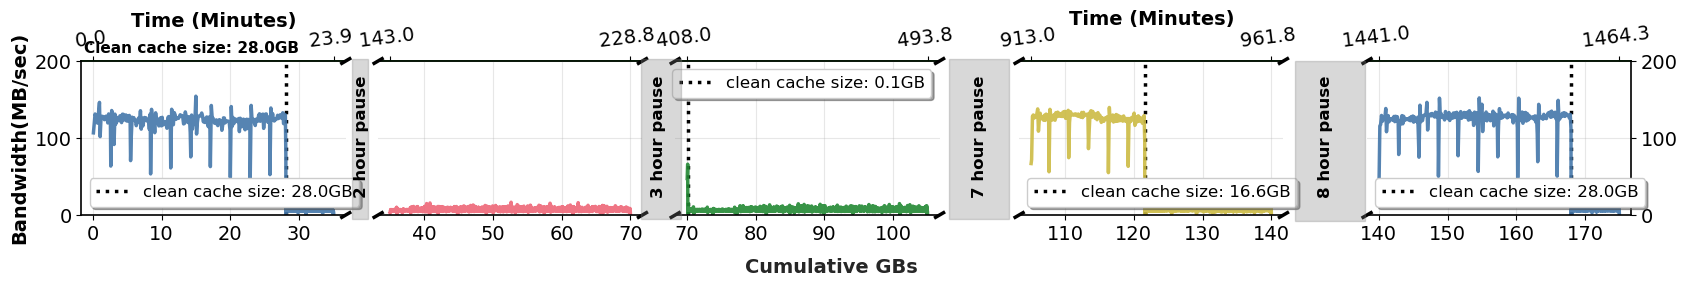

In [ ]:



# Define colorblind-friendly palette (Tol's bright scheme)
COLORS = {
    'run1': '#4477AA',    # Blue
    'run2': '#EE6677',    # Red  
    'run3': '#228833',    # Green
    'run4': '#CCBB44',    # Yellow
    'pause_bg': '#E6E6E6', # Light gray for pause backgrounds
    'break_lines': '#666666', # Dark gray for break lines
    'time_axis': '#2E8B57'   # Sea green for time axis
}

# Set up improved plotting style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 100,
    'lines.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.linewidth': 1.2,
    'font.weight': 'normal',
    'axes.labelweight': 'bold'
})



# Create the main plot
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4), layout='constrained', sharey=True)
# Create a figure and GridSpec
fig = plt.figure(figsize=(20, 2))
gs = gridspec.GridSpec(1, 9, width_ratios=[1.3, 0.018, 1.3, 0.02, 1.3, 0.25, 1.3, 0.27, 1.3], wspace=0.09)  # Adjust width_ratios and wspace as needed

# Create subplots
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])
ax3 = plt.subplot(gs[4])
ax4 = plt.subplot(gs[6])
ax5 = plt.subplot(gs[8])

# Set labels for the primary x-axis and y-axis
#ax1.set_xlabel("Cumulative GBs")
ax1.set_ylabel("Bandwidth(MB/sec)", fontsize=14, weight="bold")
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

# Optionally, remove the right y-ticks
ax1.yaxis.set_ticks_position('left')  # Only show ticks on the left side
ax1.spines['right'].set_visible(False)

ax5.yaxis.set_ticks_position('right')  # Only show ticks on the right side
ax5.spines['left'].set_visible(False)
ax5.tick_params(axis='y', labelsize=14)


for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_ylim(0, 200)

# Customize spines and ticks
for ax in [ax2, ax3, ax4]:
    # Hide all spines and ticks initially
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', left=False, right=False, labelleft=False, labelright=False)


# Map the ticks from the primary axis (cumulative_gbs) to the corresponding time values
tick_locations = np.linspace(df_grouped1['cumulative_gb'].min(), df_grouped1['cumulative_gb'].max(), 2)  # Choose tick locations (e.g., 5 ticks)
corresponding_time_values1 = np.interp(tick_locations, df_grouped1['cumulative_gb'], df_grouped1.index)  # Interpolate corresponding time values

secax1 = ax1.secondary_xaxis('top')
#Set the ticks and their labels on the secondary axis
secax1.set_xticks(tick_locations)
#secax1.set_xticklabels([f"{int(val)} s" for val in corresponding_time_values1])  # Format as minutes
secax1.set_xticklabels([f"{val/60:.1f} " for val in corresponding_time_values1])
df_grouped1['minutes'] = pd.to_numeric(df_grouped1.index)
df_grouped2['minutes'] = pd.to_numeric(df_grouped2.index)
maxindex = df_grouped1.iloc[-1].minutes + df_grouped2.iloc[-1].minutes
secax1.set_xlim(0, maxindex)
secax1.spines['top'].set_linestyle((0, (1, 1)))  # Dotted pattern (0, (1, 1))
secax1.spines['top'].set_color('green')          # Set the color to green
secax1.tick_params(axis='x', labelsize=14, rotation=7)     # Set the ticks color to green


 # Choose tick locations (e.g., 5 ticks)
last_experiment_end = int(float(secax1.get_xticklabels()[-1].get_text()))
tick_locations = np.linspace(df_grouped2['cumulative_gb'].min(), df_grouped2['cumulative_gb'].max(), 2)
corresponding_time_values1 = np.interp(tick_locations, df_grouped2['cumulative_gb'], df_grouped2.index)  # Interpolate corresponding time values
secax2 = ax2.secondary_xaxis('top')
# Set the ticks and 
secax2.spines['top'].set_linestyle((0, (1, 1)))  # Dotted pattern (0, (1, 1))
secax2.spines['top'].set_color('green')          # Set the color to green
secax2.tick_params(axis='x' , labelsize=14, rotation=7)     # Set the ticks color to greentheir labels on the secondary axis
secax2.set_xticks(tick_locations)
#secax2.set_xticklabels([f"{int(val)} s" for val in corresponding_time_values1])  # Format as seconds
secax2.set_xticklabels([f"{val/60 + last_experiment_end + 120 :.1f} " for val in corresponding_time_values1]) # Format as minutes

last_experiment_end = int(float(secax2.get_xticklabels()[-1].get_text()))
tick_locations = np.linspace(df_grouped3['cumulative_gb'].min(), df_grouped3['cumulative_gb'].max(), 2)  # Choose tick locations (e.g., 5 ticks)
corresponding_time_values1 = np.interp(tick_locations, df_grouped3['cumulative_gb'], df_grouped3.index)  # Interpolate corresponding time values
secax3 = ax3.secondary_xaxis('top')
# Set the ticks and 
secax3.spines['top'].set_linestyle((0, (1, 1)))  # Dotted pattern (0, (1, 1))
secax3.spines['top'].set_color('green')          # Set the color to green
secax3.tick_params(axis='x', labelsize=14, rotation=7)     # Set the ticks color to greentheir labels on the secondary axis
secax3.set_xticks(tick_locations)
#secax3.set_xticklabels([f"{int(val)} s" for val in corresponding_time_values1])  # Format as seconds
secax3.set_xticklabels([f"{val/60 + last_experiment_end + 180:.1f} " for val in corresponding_time_values1]) # Format as minutes

last_experiment_end = int(float(secax3.get_xticklabels()[-1].get_text()))
tick_locations = np.linspace(df_grouped5['cumulative_gb'].min(), df_grouped5['cumulative_gb'].max(), 2)  # Choose tick locations (e.g., 5 ticks)
corresponding_time_values1 = np.interp(tick_locations, df_grouped5['cumulative_gb'], df_grouped5.index)  # Interpolate corresponding time values
secax5 = ax4.secondary_xaxis('top')
# Set the ticks and 
secax5.spines['top'].set_linestyle((0, (1, 1)))  # Dotted pattern (0, (1, 1))
secax5.spines['top'].set_color('green')          # Set the color to green
secax5.tick_params(axis='x', labelsize=14, rotation=7)     # Set the ticks color to greentheir labels on the secondary axis
secax5.set_xticks(tick_locations)
#secax5.set_xticklabels([f"{int(val)} s" for val in corresponding_time_values1])  # Format as seconds
secax5.set_xticklabels([f"{val/60 + last_experiment_end + 420:.1f} " for val in corresponding_time_values1]) # Format as minutes


last_experiment_end = int(float(secax5.get_xticklabels()[-1].get_text()))
tick_locations = np.linspace(df_grouped6['cumulative_gb'].min(), df_grouped6['cumulative_gb'].max(), 2)  # Choose tick locations (e.g., 5 ticks)
corresponding_time_values1 = np.interp(tick_locations, df_grouped6['cumulative_gb'], df_grouped6.index)  # Interpolate corresponding time values
secax6 = ax5.secondary_xaxis('top')
# Set the ticks and 
secax6.spines['top'].set_linestyle((0, (1, 1)))  # Dotted pattern (0, (1, 1))
secax6.spines['top'].set_color('green')          # Set the color to green
secax6.tick_params(axis='x', labelsize=14, rotation=7)     # Set the ticks color to greentheir labels on the secondary axis
secax6.set_xticks(tick_locations)
#secax5.set_xticklabels([f"{int(val)} s" for val in corresponding_time_values1])  # Format as seconds
secax6.set_xticklabels([f"{val/60 + last_experiment_end + 480:.1f} " for val in corresponding_time_values1]) # Format as minutes

ax2.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='x', labelsize=14)
ax4.tick_params(axis='x', labelsize=14)
ax5.tick_params(axis='x', labelsize=14)

#secax2.sharex(secax1)
ax1.axvline(x=first_cumulative_gb_run1, color='black', linestyle=':', label="clean cache size: " + str(round(cache_size_run1, 1)) + "GB")
ax1.legend(loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=12)
ax1.plot(df_grouped1['cumulative_gb'], df_grouped1['data_written_bytes'], color=COLORS["run1"], linewidth=2.5, alpha=0.9, label="Run1")
#df_grouped2['cumulative_gb'] = df_grouped2['cumulative_gb'] + df_grouped1.iloc[-1].cumulative_gb
ax2.plot(df_grouped2['cumulative_gb'], df_grouped2['data_written_bytes'], color=COLORS["run2"], linewidth=2.5, alpha=0.9, label="Run2")

ax3.axvline(x=first_cumulative_gb_run3, color='black', linestyle=':', label="clean cache size: " + str(round(cache_size_run3, 1)) + "GB")
ax3.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=12)
ax3.plot(df_grouped3['cumulative_gb'], df_grouped3['data_written_bytes'], color=COLORS["run3"], linewidth=2.5, alpha=0.9, label="Run3")

ax4.axvline(x=first_cumulative_gb_run5, color='black', linestyle=':', label="clean cache size: " + str(round(cache_size_run5, 1)) + "GB")
ax4.legend(loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=12)
ax4.plot(df_grouped5['cumulative_gb'], df_grouped5['data_written_bytes'], color=COLORS["run4"], linewidth=2.5, alpha=0.9, label="Run4")

ax5.axvline(x=first_cumulative_gb_run6, color='black', linestyle=':', label="clean cache size: " + str(round(cache_size_run1, 1)) + "GB")
ax5.legend(loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=12)
ax5.plot(df_grouped6['cumulative_gb'], df_grouped6['data_written_bytes'], color=COLORS["run1"], linewidth=2.5, alpha=0.9, label="Run5")

# Add diagonal lines to indicate the break
d = .015  # size of the diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)


kwargs.update(transform=ax2.transAxes)  # switch to the right axis
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax3.transAxes)  # switch to the right axis
ax3.plot((-d, +d), (-d, +d), **kwargs)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)
ax3.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
ax3.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax4.transAxes)  # switch to the right axis
ax4.plot((-d, +d), (-d, +d), **kwargs)
ax4.plot((-d, +d), (1-d, 1+d), **kwargs)
ax4.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
ax4.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax5.transAxes)  # switch to the right axis
ax5.plot((-d, +d), (-d, +d), **kwargs)
ax5.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add a rectangle exactly between the diagonal lines
mid_x = (ax1.get_position().x1 + ax2.get_position().x0) / 2  # Midpoint between the subplots
rect1 = plt.Rectangle((mid_x-0.005, 0.09), 0.008, 0.8, transform=fig.transFigure, color="gray", alpha=0.3)
fig.patches.append(rect1)
# Add text inside the rectangle
fig.text(mid_x, 0.5, "2 hour pause", ha="center", va="center", fontsize=12, color="black", weight="bold", rotation=90)


mid_x = (ax2.get_position().x1 + ax3.get_position().x0) / 2  # Midpoint between the subplots
rect2 = Rectangle((mid_x-0.009, 0.09), 0.02, 0.8, transform=fig.transFigure, color="gray", alpha=0.3)
fig.patches.append(rect2)
# Add text inside the rectangle
fig.text(mid_x, 0.5, "3 hour pause", ha="center", va="center", fontsize=12, color="black", weight="bold", rotation=90)


mid_x = (ax3.get_position().x1 + ax4.get_position().x0) / 2  # Midpoint between the subplots
rect3 = Rectangle((mid_x - 0.015, 0.09), 0.03, 0.8, transform=fig.transFigure, color="gray", alpha=0.3)
fig.patches.append(rect3)
# Add text inside the rectangle
fig.text(mid_x, 0.5, "7 hour pause", ha="center", va="center", fontsize=12, color="black", weight="bold", rotation=90)


mid_x = (ax4.get_position().x1 + ax5.get_position().x0) / 2  # Midpoint between the subplots
rect5 = Rectangle((mid_x - 0.015, 0.08), 0.035, 0.8, transform=fig.transFigure, color="gray", alpha=0.3)
fig.patches.append(rect5)
# Add text inside the rectangle
fig.text(mid_x, 0.5, "8 hour pause", ha="center", va="center", fontsize=12, color="black", weight="bold", rotation=90)

secax1.set_xlabel("Time (Minutes)", labelpad=0, loc='center', fontsize=14, weight="bold")
#secax2.set_xlabel("Time (Seconds)", labelpad=0, loc='center', fontsize=11)
#secax3.set_xlabel("Time (Seconds)", labelpad=0, loc='center', fontsize=11)
secax5.set_xlabel("Time (Minutes)", labelpad=0, loc='center', fontsize=14, weight="bold")
sns.set_context("notebook", font_scale=1.2)
sns.set_style("ticks") 
sns.set_palette("muted")
sns.set_context("talk")

fig.supxlabel("Cumulative GBs", fontsize=14, weight="bold", y=-0.2)
#plt.tight_layout(rect=[0, 0, 1, 0.3])  # Leave space for the suptitle
#fig.suptitle("Asynchronous 1MB uniform random writes to DM-Hybrid with pauses to elucidate cache cleaning", fontsize=14)
plt.savefig("/home/surbhi/Downloads/cache-pause.pdf", format="pdf", bbox_inches='tight')# Add a rectangle exactly between the diagonal lines
plt.show()


In [27]:
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_ylim(0, 200)  # Changed from 140 to 200